In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cybersecurity_dataset.csv")

In [4]:
df

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated
2,0ef24a20-1d25-41fa-81b8-e19fb63e9e4c,2022-01-04 09:08:07,171.153.115.83,76.187.142.133,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...,Ransomware,High,False,Artist though type imagine food push.,Eradicated
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained
4,783fd153-6b88-44c1-8db5-d882300088cc,2021-11-24 02:04:33,120.43.64.52,113.82.34.164,Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...,Malware,Medium,False,Push always least police it range either.,Eradicated
...,...,...,...,...,...,...,...,...,...,...
19995,34e609d3-ce8e-49f3-a552-776496bd0eab,2022-10-26 15:11:16,50.182.104.127,71.205.220.209,Opera/9.90.(X11; Linux i686; kok-IN) Presto/2....,Ransomware,Critical,False,Forward something wife.,Recovered
19996,ab090f66-e2ba-4560-ab18-254e91bd042d,2022-07-20 08:59:24,68.76.164.160,174.127.187.150,Mozilla/5.0 (iPod; U; CPU iPhone OS 4_2 like M...,Ransomware,Low,True,Fund method election possible.,Eradicated
19997,387ec9f5-e808-4753-84bb-deeaf679d592,2020-05-28 22:34:07,176.103.72.227,214.189.241.210,Opera/9.60.(X11; Linux x86_64; yi-US) Presto/2...,Ransomware,Medium,False,Network minute act reflect.,Contained
19998,42106391-4666-4c50-9403-70af8084896f,2021-03-10 14:58:36,42.225.43.82,41.192.165.72,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_5...,Malware,Critical,False,Amount sit ten.,Contained


In [5]:
df.head()

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated
2,0ef24a20-1d25-41fa-81b8-e19fb63e9e4c,2022-01-04 09:08:07,171.153.115.83,76.187.142.133,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...,Ransomware,High,False,Artist though type imagine food push.,Eradicated
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained
4,783fd153-6b88-44c1-8db5-d882300088cc,2021-11-24 02:04:33,120.43.64.52,113.82.34.164,Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...,Malware,Medium,False,Push always least police it range either.,Eradicated


In [6]:
df.shape

(20000, 10)

In [7]:
df.columns

Index(['Event ID', 'Timestamp', 'Source IP', 'Destination IP', 'User Agent',
       'Attack Type', 'Attack Severity', 'Data Exfiltrated',
       'Threat Intelligence', 'Response Action'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Event ID             20000 non-null  object
 1   Timestamp            20000 non-null  object
 2   Source IP            20000 non-null  object
 3   Destination IP       20000 non-null  object
 4   User Agent           20000 non-null  object
 5   Attack Type          20000 non-null  object
 6   Attack Severity      20000 non-null  object
 7   Data Exfiltrated     20000 non-null  bool  
 8   Threat Intelligence  20000 non-null  object
 9   Response Action      20000 non-null  object
dtypes: bool(1), object(9)
memory usage: 1.4+ MB


In [9]:
df.isnull().sum()

Event ID               0
Timestamp              0
Source IP              0
Destination IP         0
User Agent             0
Attack Type            0
Attack Severity        0
Data Exfiltrated       0
Threat Intelligence    0
Response Action        0
dtype: int64

In [10]:
df.columns = df.columns.str.strip()

In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Event ID             20000 non-null  object        
 1   Timestamp            20000 non-null  datetime64[ns]
 2   Source IP            20000 non-null  object        
 3   Destination IP       20000 non-null  object        
 4   User Agent           20000 non-null  object        
 5   Attack Type          20000 non-null  object        
 6   Attack Severity      20000 non-null  object        
 7   Data Exfiltrated     20000 non-null  bool          
 8   Threat Intelligence  20000 non-null  object        
 9   Response Action      20000 non-null  object        
dtypes: bool(1), datetime64[ns](1), object(8)
memory usage: 1.4+ MB


In [13]:
df['Year'] = df['Timestamp'].dt.year

df['Month'] = df['Timestamp'].dt.month

df['Day'] = df['Timestamp'].dt.day

In [14]:
df[['Timestamp', 'Year', 'Month', 'Day']].head()

,Timestamp,Year,Month,Day
0,2020-02-07 23:46:57,2020,2,7
1,2021-05-25 19:03:44,2021,5,25
2,2022-01-04 09:08:07,2022,1,4
3,2022-10-12 19:48:43,2022,10,12
4,2021-11-24 02:04:33,2021,11,24


In [15]:
df['Year'].value_counts().sort_index()

Year
2020    4935
2021    4836
2022    4887
2023    4965
2024     377
Name: count, dtype: int64

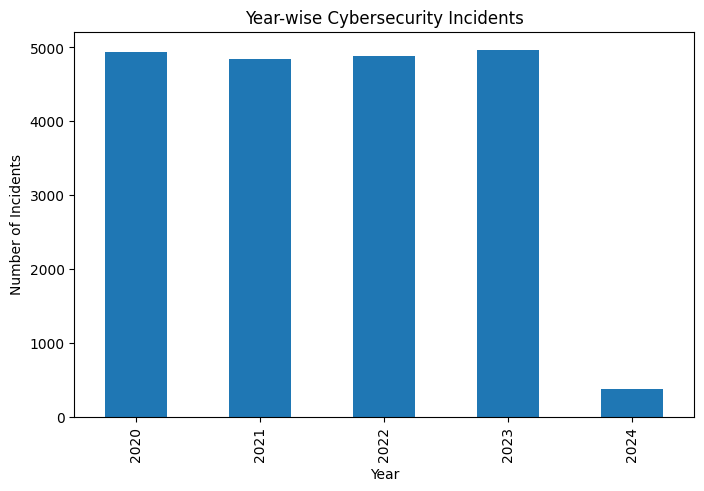

In [16]:
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

year_counts.plot(kind='bar')

plt.title('Year-wise Cybersecurity Incidents')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')

plt.show()

In [17]:
df['Month'].value_counts().sort_index()

Month
1     2025
2     1554
3     1707
4     1617
5     1689
6     1587
7     1626
8     1689
9     1635
10    1645
11    1608
12    1618
Name: count, dtype: int64

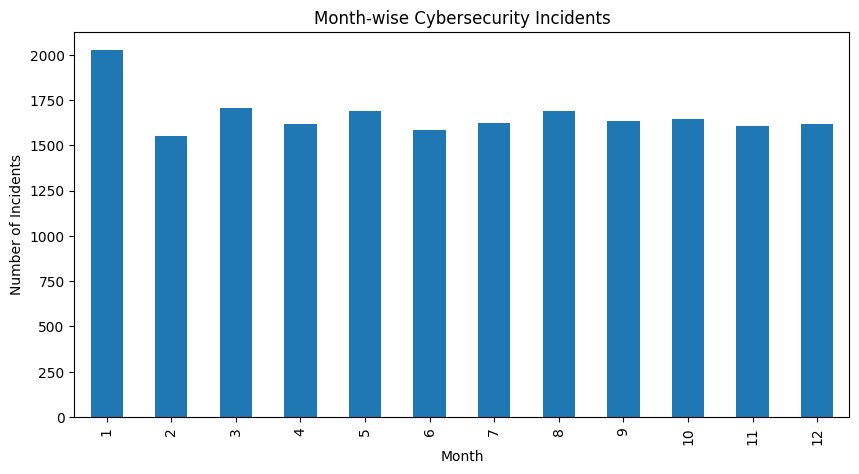

In [18]:
month_counts = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))

month_counts.plot(kind='bar')

plt.title('Month-wise Cybersecurity Incidents')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')

plt.show()

In [19]:
df['Attack Type'].value_counts()

Attack Type
Malware           4081
Phishing          4056
Insider Threat    3968
Ransomware        3955
DDoS              3940
Name: count, dtype: int64

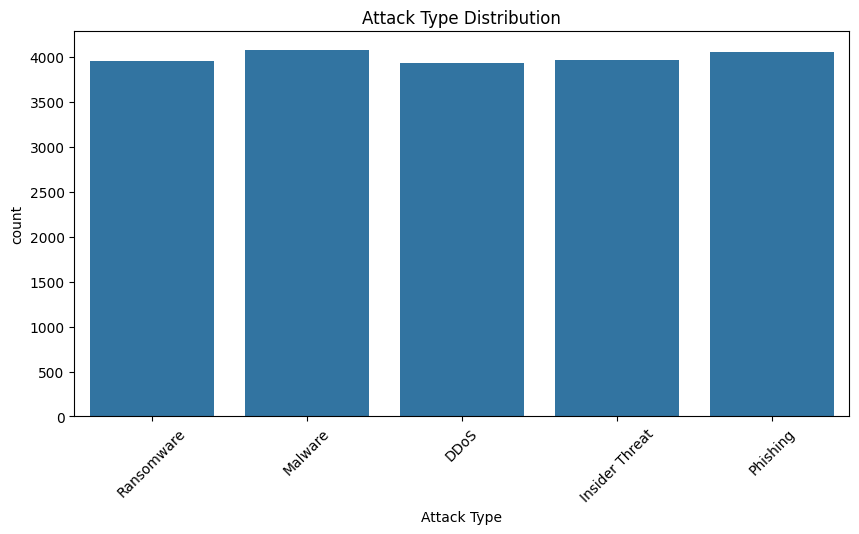

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Attack Type',
    data=df
)

plt.title('Attack Type Distribution')

plt.xticks(rotation=45)

plt.show()

In [21]:
df['Attack Severity'].value_counts()

Attack Severity
Low         5073
High        5053
Critical    5025
Medium      4849
Name: count, dtype: int64

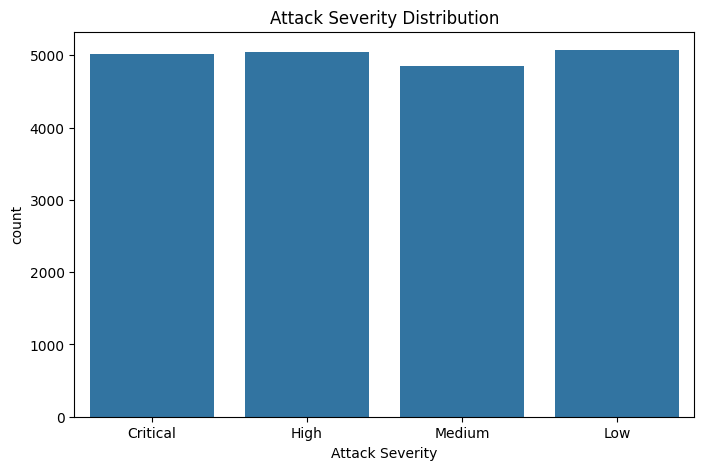

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Attack Severity',
    data=df
)

plt.title('Attack Severity Distribution')

plt.show()

In [23]:
df['Data Exfiltrated'].value_counts()

Data Exfiltrated
False    18081
True      1919
Name: count, dtype: int64

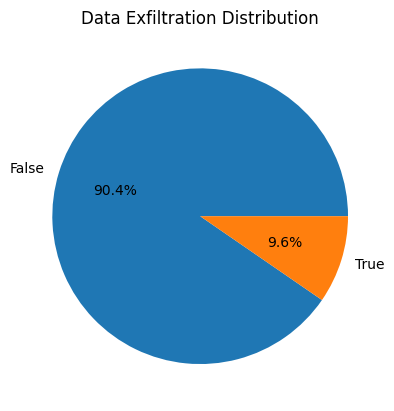

In [25]:
df['Data Exfiltrated'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
   
)

plt.title('Data Exfiltration Distribution')

plt.ylabel('')

plt.show()

In [29]:
severity_attack =pd.crosstab(df['Attack Type'], df['Attack Severity'])

In [30]:
severity_attack

Attack Severity,Critical,High,Low,Medium
Attack Type,,,,
DDoS,981,1019,1030,910
Insider Threat,1020,996,1010,942
Malware,995,1078,1026,982
Phishing,1031,1002,1021,1002
Ransomware,998,958,986,1013


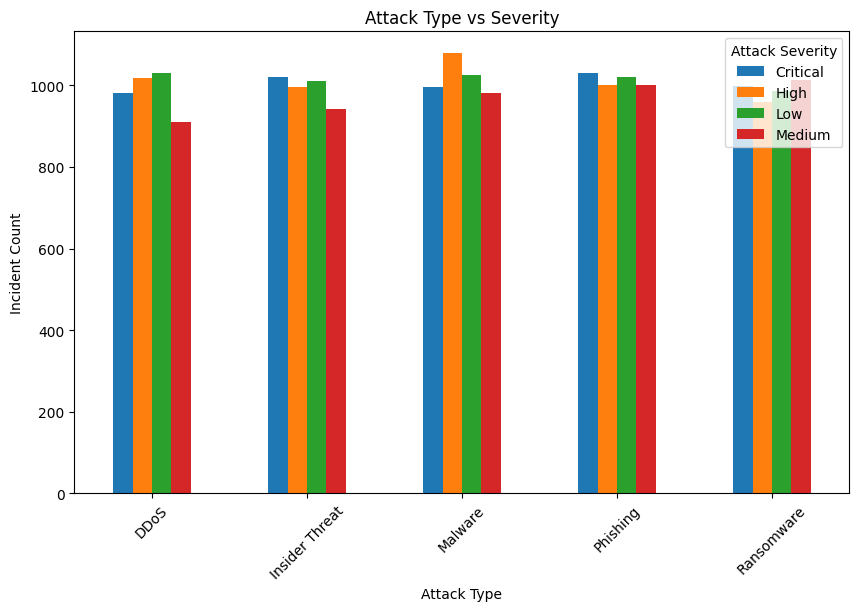

In [32]:
severity_attack.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Attack Type vs Severity')

plt.ylabel('Incident Count')

plt.xticks(rotation = 45)

plt.show()

In [33]:
exfiltration_attack = pd.crosstab(
    df['Attack Type'],
    df['Data Exfiltrated']
)

exfiltration_attack

Data Exfiltrated,False,True
Attack Type,,
DDoS,3568,372
Insider Threat,3609,359
Malware,3637,444
Phishing,3679,377
Ransomware,3588,367


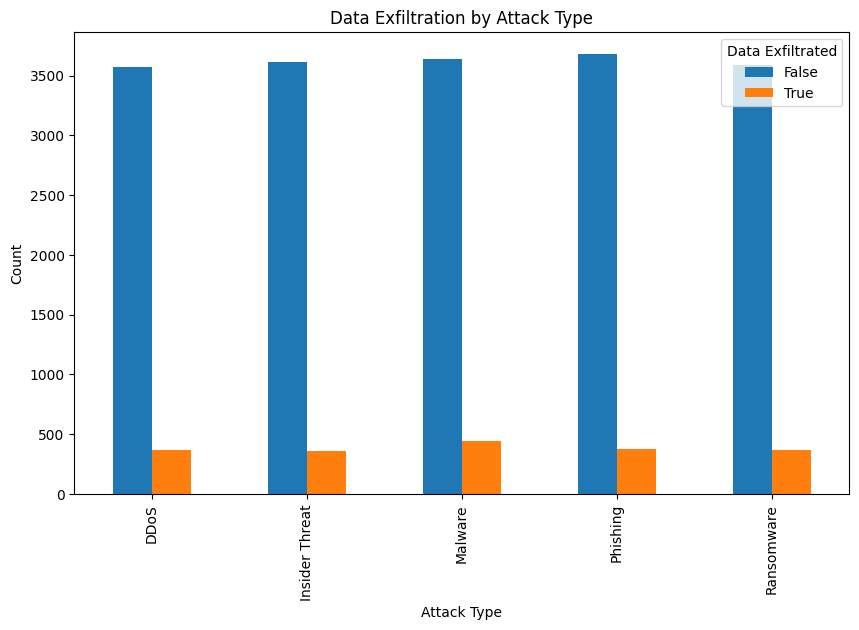

In [34]:
exfiltration_attack.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Data Exfiltration by Attack Type')

plt.ylabel('Count')

plt.show()

In [36]:
df['Response Action'].value_counts()

Response Action
Eradicated    5063
Blocked       5020
Recovered     4980
Contained     4937
Name: count, dtype: int64

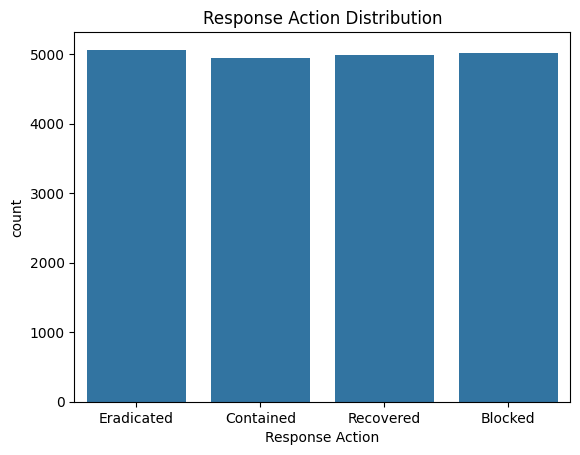

In [42]:
plt.Figure(figsize=(8,5))

sns.countplot(
    x='Response Action',
    data=df
)
plt.title('Response Action Distribution')

plt.show()

In [45]:
critical_df = df[df['Attack Severity'] == 'Critical']
critical_df

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action,Year,Month,Day
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated,2020,2,7
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated,2021,5,25
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained,2022,10,12
10,eef11ebf-568a-4da5-89d2-88e2410c6798,2020-01-18 07:03:02,17.33.248.161,62.252.69.248,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...,Phishing,Critical,False,Himself leader issue land difficult.,Contained,2020,1,18
11,f0a554c1-26e0-4220-8647-023cd8a67097,2020-09-29 22:20:08,141.136.226.234,222.56.160.84,Opera/9.76.(X11; Linux i686; ts-ZA) Presto/2.9...,Malware,Critical,False,Activity indeed trouble material friend say de...,Recovered,2020,9,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19989,1b05fae4-b6f0-4236-b7bc-50769190d233,2020-07-02 10:03:33,17.224.30.81,2.254.155.206,Mozilla/5.0 (Windows NT 10.0) AppleWebKit/531....,DDoS,Critical,False,Resource job feeling reality various present.,Eradicated,2020,7,2
19993,e3ad49c2-3f38-42e7-b3eb-9bf0c7f1c1f5,2021-02-20 22:02:52,86.241.157.118,86.24.200.225,Opera/8.15.(X11; Linux i686; tt-RU) Presto/2.9...,Phishing,Critical,False,Situation director analysis travel film educat...,Recovered,2021,2,20
19994,310052f4-cd4b-45c7-b641-64111c01cec2,2023-10-22 17:53:46,98.73.171.22,95.176.239.224,Opera/9.25.(Windows NT 6.1; ckb-IQ) Presto/2.9...,Insider Threat,Critical,False,Laugh it leave age month garden add.,Contained,2023,10,22
19995,34e609d3-ce8e-49f3-a552-776496bd0eab,2022-10-26 15:11:16,50.182.104.127,71.205.220.209,Opera/9.90.(X11; Linux i686; kok-IN) Presto/2....,Ransomware,Critical,False,Forward something wife.,Recovered,2022,10,26


In [46]:
critical_df.shape

(5025, 13)

In [47]:
critical_df['Attack Type'].value_counts()

Attack Type
Phishing          1031
Insider Threat    1020
Ransomware         998
Malware            995
DDoS               981
Name: count, dtype: int64

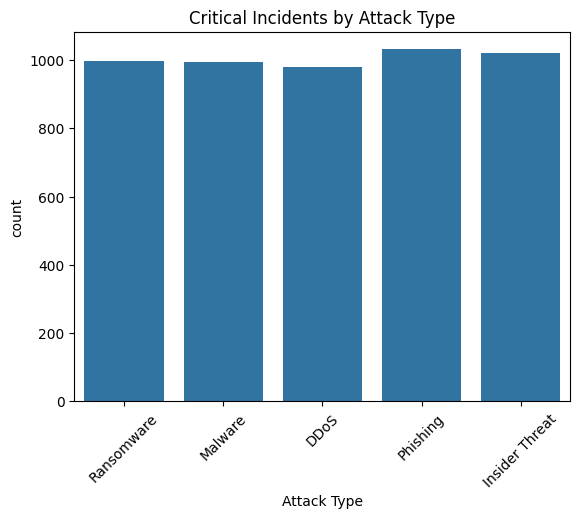

In [48]:
sns.countplot(
    x='Attack Type',
    data=critical_df
)

plt.title('Critical Incidents by Attack Type')

plt.xticks(rotation=45)

plt.show()

In [50]:
df.head()

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action,Year,Month,Day
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated,2020,2,7
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated,2021,5,25
2,0ef24a20-1d25-41fa-81b8-e19fb63e9e4c,2022-01-04 09:08:07,171.153.115.83,76.187.142.133,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...,Ransomware,High,False,Artist though type imagine food push.,Eradicated,2022,1,4
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained,2022,10,12
4,783fd153-6b88-44c1-8db5-d882300088cc,2021-11-24 02:04:33,120.43.64.52,113.82.34.164,Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...,Malware,Medium,False,Push always least police it range either.,Eradicated,2021,11,24


In [51]:
df.to_csv(
    'cybersecurity_cleaned.csv',
    index=False
)